# Laboratório 2 – Testes de Hipóteses [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/labs/Laborat%C3%B3rio%202%20%E2%80%93%20Testes%20de%20Hip%C3%B3teses/images/colag_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 6.5%;">](https://colab.research.google.com/github/urielmoreirasilva/ICE072/blob/main/labs/Laborat%C3%B3rio%202%20%E2%80%93%20Testes%20de%20Hip%C3%B3teses/Laborat%C3%B3rio%202%20%E2%80%93%20Testes%20de%20Hip%C3%B3teses.ipynb) [<img src="https://raw.githubusercontent.com/urielmoreirasilva/ICE072/main/labs/Laborat%C3%B3rio%202%20%E2%80%93%20Testes%20de%20Hip%C3%B3teses/images/github_logo.svg" style="float: right; margin-right: 0%; vertical-align: middle; width: 3.25%;">](https://github.com/urielmoreirasilva/ICE072/blob/main/labs/Laborat%C3%B3rio%202%20%E2%80%93%20Testes%20de%20Hip%C3%B3teses/Laborat%C3%B3rio%202%20%E2%80%93%20Testes%20de%20Hip%C3%B3teses.ipynb)

Bem-vindo ao Laboratório 2! Nesta tarefa, desenvolveremos uma compreensão mais aprofundada sobre dos testes de hipóteses.

Você deve concluir todo este laboratório e enviá-lo ao Moodle até às 23h59 da data de vencimento.

### Referências
- [CIT: Capítulo 11](https://inferentialthinking.com/)
- Aulas: Tópico 15. 

Material adaptado do [DSC10 (UCSD)](https://dsc10.com/) por [Flavio Figueiredo (DCC-UFMG)](https://flaviovdf.io/fcd/) e [Uriel Silva (DEST-UFMG)](https://urielmoreirasilva.github.io)

In [1]:
## Imports para esse laboratório
import numpy as np
import pandas as pd
import math

## Opções do MatplotLib 
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Toque Terapêutico 👆

O Toque Terapêutico (TT) é uma terapia energética que os profissionais afirmam poder promover saúde e relaxamento. Os profissionais colocam as mãos perto do paciente e dizem que são capazes de detectar e manipular o chamado Campo de Energia Humana (HEF, do inglês _Human Energy Field_) do paciente.
O TT foi popular ao longo do século 20 e foi apontado como uma ótima maneira de trazer equilíbrio à saúde de uma pessoa. [Você pode ler mais sobre o TT aqui](https://www.mountsinai.org/health-library/treatment/therapeutic-touch).

### Experiência de Emily Rosa

Em 1996, Emily Rosa tinha 9 anos e teve ampla exposição ao mundo do TT devido aos seus pais, que eram médicos e céticos em relação à ideia do TT. Para seu projeto de feira de ciências da 4ª série, Emily decidiu testar se os profissionais de TT poderiam realmente interagir com o HEF de uma pessoa.

Com cada praticante, Emily realizou o seguinte experimento várias vezes ao longo de alguns dias:

1. Primeiro, ela e o praticamente se sentavam em uma mesa, separados por uma espécie de tábua (para que eles não pudessem se ver).
1. Em seguida, ela pedia que o praticante colocasse ambas as mãos em uma abertura na tábua.
1. Emily jogaria uma moeda honesta para determinar aleatoriamente se deveria colocar as mãos perto da mão esquerda ou direita do praticante.
1. Finalmente, Emily pediria ao praticante de TT que especificasse se conseguiria detectar o Campo de Energia Humana (HEF) de Emily perto da mão esquerda ou da mão direita.

No geral, Emily realizou 280 experimentos (como seus pais trabalhavam na área médica, ela teve fácil acesso aos praticantes de TT), e desses os praticantes de TT escolheram a mão correta 123 vezes.

- O principal objetivo de Emily com seu experimento era testar se os acertos dos praticantes de TT eram ou não aleatórias, como o resultado de um lançamento de uma moeda (o raciocínio dela foi muito similar à maioria dos experimentos médicos, onde queremos testar se um _tratamento_ realmente tem efeito, ou se a melhora dos pacientes pode ser atribuída simplesmente ao acaso – ao que denominamos efeito _placebo_).

### Testes de Hipóteses

Vamos agora formular o experimento de Emily como um teste de hipóteses!

**Pergunta 1.1.** Defina nas células de texto abaixo as hipóteses nula $H_0$ e alternativa $H_1$ relativas ao experimento de Emily Rosa. Lembre-se que a hipótese nula $H_0$ deve levar à um modelo **bem definido** (do qual podemos simular e logo calcular probabilidades), enquanto $H_1$ pode ser mais genérica (e usualmente será o complementar de $H_0$).

_<ins> Dica</ins>_: pense no que a ideia de Emily Rosa implica em termos de algum parâmetro sobre o qual queremos inferir, e o qual seria o "valor esperado" para esse parâmetro. Pode ajudar também refletir um pouco sobre o que seriam a população e o modelo estatístico nesse caso.

> $H_0 \! :$ $\,$ $...$

> $H_1 \! :$ $\,$ $...$

**Importante**: volte à essa pergunta depois de terminar essa seção e reflita um pouco sobre suas hipóteses. Se você tivesse escolhido outras hipóteses, suas conclusões poderiam ter sido diferentes?

**Pergunta 1.2.** Selecione entre as alternativas abaixo uma estatística de teste $T$ "válida" para testar as hipóteses definidas na Pergunta 1.1, e escreva a alternativa escolhida na célula de texto que se segue. Lembre-se que uma estatística de teste objetiva medir a evidência na amostra _a favor_ ou _contra_ $H_0$.

**A**. $T =$ número esperado de acertos.

**B**. $T =$ número observado de acertos.

**C**. $T = $ diferença entre o número observado e esperado de acertos.

**D**. $T = $ diferença absoluta entre o número observado e esperado de acertos.

**E**. $T = $ número total de experimentos.

**F**. $T = $ proporção esperada de acertos.

**G**. $T = $ proporção observada de acertos.

**H**. $T = $ diferença entre a proporção observada e esperada de acertos.

**I**. $T = $ diferença absoluta entre a proporção observada e esperada de acertos. 

> ...

**Pergunta 1.3.**  Escreva abaixo uma função chamada `calculate_mean_based_estimate` que calcula a estatística de teste $T$ definida na Pergunta 1.2, da seguinte forma:

1. Essa função deve tomar como argumento um `float`, que deve tomar o nome de `obs_value`.
1. Ao invocarmos essa função, ela deve retornar a estatística de teste $T$.

_<ins> Dica</ins>_: Isso não é absolutamente necessário, mas você pode simplificar um pouco sua vida se sua estatística de teste for também função do que é _esperado_ em $H_0$! Caso opte por fazer isso, denomine o valor esperado de `expected_value`.

In [60]:
## Descomente e execute
def calculate_test_stat(obs_value, expected_value):
    return(1e2*(obs_value - expected_value))

**Pergunta 1.4.** Use a função `calculate_test_stat` definida na Pergunta 1.3 para calcular a estatística de teste observada $T_{obs}$ para o experimento de Emily. Atribua o valor a `T_obs`.

In [61]:
## Descomente e execute
obs_value = 123/280
expected_value = 0.50
calculate_test_stat(obs_value, expected_value)

-6.071428571428572

Nesse ponto, surge naturalmente a seguinte pergunta:

> Supondo que a hipótese nula $H_0$ seja verdadeira, o valor da estatística de teste $T_{obs}$ calculado acima é "típico" ou "atípico"? 🤔

Em outras palavras: sob $H_0$, a probabilidade de obtermos um valor $T$ "próximo" de $T_{obs}$ é alta ou baixa? 

- Lembre que se a probabilidade de obtermos um valor próximo de $T_{obs}$ for muito baixa (menor do que o nosso nível de significância $\alpha$), então _rejeitamos $H_0$_, uma vez que nesse caso o valor de $T_{obs}$ é considerado "extremo" ou "atípico" demais para ocorrer por pura aleatoriedade.
- Por outro lado, se a probabilidade de obtermos um valor próximo de $T_{obs}$ for relativamente alta (maior do que o nosso nível de significância $\alpha$), então _aceitamos $H_0$_, uma vez que nesse caso o valor de $T_{obs}$ não é considerado tão extremo ou atípico demais para ocorrer por pura aleatoriedade.

Para encontrar a probabilidade na qual estamos interessados, no que segue abaixo vamos aproximar a distribuição amostral de $T$ sob $H_0$ via simulação, e então descobriremos o quão extremo o valor de $T_{obs}$ realmente é! 

**Pergunta 1.5.** Escreva abaixo uma função chamada `simulate_test_stat` que simula o valor de uma estatística de teste $T$ sob $H_0$, da seguinte forma:

1. Essa função deve tomar como argumentos:
    1. um `float` `n` contendo o número de experimentos realizados, $n$;
    1. um `float` `p_0` contendo a proporção esperada de acertos sob $H_0$, $p_0$;
    1. uma função `statistic`, que calcula a estatística de teste $T$ definida na Pergunta 1.2.
1. Ao invocarmos essa função, ela deve retornar a estatística de teste $T$ `statistic` como função de $n$ e $p_0$.

_<ins> Dica #1</ins>_: utilize a função `np.random.binomial` com argumentos $n$ e $p_0$ para simular o _número_ de sucessos sob $H_0$, e então transformar esse número apropriadamente em sua estatística de teste $T$.

_<ins> Dica #2</ins>_: caso sua função `statistic` tome argumentos extras, você pode declará-los como variáveis locais/globais (isto é, dentro ou fora da função `simulate_test_stat`), ou tomá-los como argumentos extras em `simulate_test_stat` e utilizá-los na invocação de `statistic`.  

In [62]:
def simulate_test_stat(n, p_0, statistic):
    counts = np.random.binomial(n = n, p = p_0)
    return(statistic(obs_value = counts/n, expected_value = p_0))

**Pergunta 1.6.** Invoque a função `simulate_test_stat` definida na Pergunta 1.5 na célula de código abaixo. Chame o resultado de `one_simulated_test_stat`.

In [63]:
## Descomente e execute
n = 280
p_0 = 0.50

one_simulated_test_stat = simulate_test_stat(n, p_0, calculate_test_stat)
one_simulated_test_stat

3.57142857142857

Após aprendermos a simular _um_ valor de $T$ sob $H_0$, vamos agora construir uma distribuição com vários desses valores simulados!

**Pergunta 1.7.** Complete a célula de código abaixo, que atribui `simulated_distribution` a um `Array` de `num_repetitions`= 10.000 valores da estatística de teste simulada sob $H_0$.

_<ins> Dica</ins>_: basta utilizar o que você já sabe sobre _loops_, e invocar a função `simulate_test_stat` definida na Pergunta 1.6.

In [64]:
## Descomente e execute
# ----

## Fixando a semente aleatória (para garantir reproducibilidade)
np.random.seed(42)

## Parâmetros da simulação
num_repetitions = int(1e4)
n = 280
p_0 = 0.50

## Loop principal
simulated_distribution = np.array([])
for i in np.arange(num_repetitions):
    simulated_value = simulate_test_stat(n, p_0, calculate_test_stat)
    simulated_distribution = np.append(simulated_distribution, simulated_value)
simulated_distribution

array([-1.78571429,  0.71428571, -4.64285714, ...,  1.42857143,
        1.42857143, -1.78571429], shape=(10000,))

Vamos agora visualizar nossa distribuição amostral empírica de de $T$ sob $H_0$, e ver o quão "atípico" o valor de $T_{obs}$ realmente é nessa distribuição. 

**Pergunta 1.8.** Execute a célula de código abaixo, que elabora um histograma de `simulated_distribution` e destaca o valor de $T_{obs}$ nessa distribuição como uma barra vertical sólida de cor preta.

In [65]:
T_obs = calculate_test_stat(obs_value = 123/280, expected_value = 0.50)
T_obs

-6.071428571428572

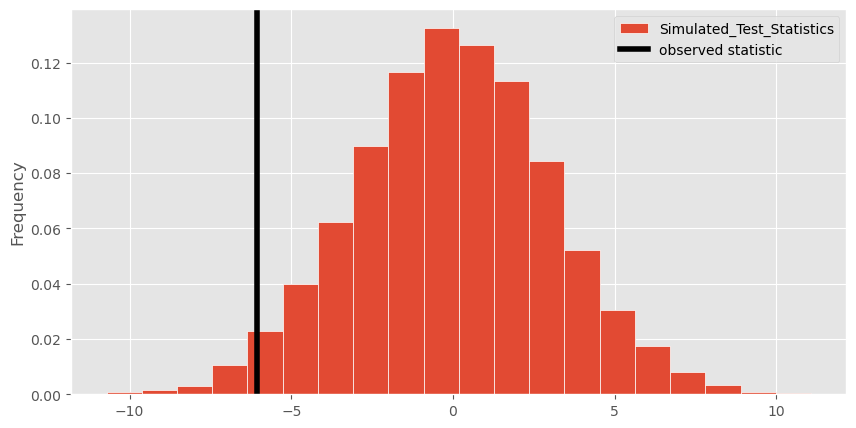

In [66]:
## Descomente e execute
t = pd.DataFrame().assign(Simulated_Test_Statistics=simulated_distribution)
t.plot(kind='hist', density=True, ec='w', bins= 20, figsize=(10, 5))
plt.axvline(x=T_obs, color='black', label='observed statistic', linewidth=4)
plt.legend();

Embora a evidência visual pode sugerir que o valor observado no experimento de Emily seja ou não atípico/extremo, vamos agora quantificar essa noção! 

**Pergunta 1.9.** Modifique a célula de código abaixo para calcular o p-valor associado ao teste dessa questão, e atribua esse valor à `emily_p_val`. Lembre que o p-valor pode ser informalmente definido como "a probabilidade de obtermos valores mais extremos do que $T_{obs}$", isto é, valores que nos levariam cada vez mais à rejeição de $H_0$.

_<u>Dica</u>_: use a função `np.count_nonzero` para contar o _número_ de valores de $T$ sob $H_0$ que satisfaçam a definição acima, e divida esse número pelo número de simulações `num_repetitions` definido na Pergunta 1.8 (ou utilizando a função `len` no DataFrame em questão, ou ainda utilizando `.shape[0]`).

In [55]:
len(simulated_distribution)

10000

In [67]:
emily_p_val = np.count_nonzero(simulated_distribution < T_obs)
emily_p_val / simulated_distribution.shape[0]

np.float64(0.0175)

**Pergunta 1.10.** Escreva na célula de texto abaixo suas conclusões sobre o teste de hipóteses realizado acima. Formalmente, você aceita ou rejeita $H_0$ ao nível $\alpha = 5\%$ de significância? E informalmente, o que isso te leva a concluir sobre a eficácia do Toque Terapêutico? Comente.

> ...

#### Epílogo

O Toque Terapêutico caiu em desuso após esse experimento, que acabou sendo [
aceito em um periódico de prestígio da área médica](https://pubmed.ncbi.nlm.nih.gov/9533499/). 

Os praticantes de TT reagiram e acusaram Emily e sua família de adulterar os resultados, enquanto alguns alegaram que as más energias de Emily em relação ao Toque Terapêutico dificultava a leitura de seu HEF...

## 2. Anúncios no YouTube ▶️

O YouTube, a maior plataforma de compartilhamento de vídeos do mundo, gera receita com anúncios que aparecem antes e durante os vídeos.

Suponha que o YouTube divulgue publicamente uma declaração revelando que 94% dos seus anúncios podem ser ignorados (o que significa que, supostamente, apenas 6% dos seus anúncios não podem ser ignorados).

King Triton, o fiel mascote da UCSD, decidiu testar se esta afirmação era verdadeira!

O experimento de King Triton foi conduzido assim: 

- Ele abriu aleatoriamente vários vídeos do YouTube e registrou se os anúncios em cada vídeo podiam ou não ser ignorados;
- Ele assistiu a um número de vídeos necessários para chegar até 100 anúncios, e descobriu que _16 desses não eram puláveis_ (ou, equivalentemente, que  _apenas 84% eram puláveis_).

King Triton está irritado e acredita que a reivindicação de 94% do YouTube é muito alta!

**Pergunta 2.1.** Defina nas células de texto abaixo as hipóteses nula $H_0$ e alternativa $H_1$ relativas ao experimento do King Triton.

_<u>Dica</u>_: note que existe uma _simetria_ entre 94% dos anúncios _serem puláveis_ e 6% dos anúncios _não serem puláveis_. Dessa forma, de qualquer modo que você defina $H_0$ e $H_1$ (desde que essa definição esteja correta, claro!), suas conclusões devem ser as mesmas.  

> $H_0 \! :$ $\,$ $...$

> $H_1 \! :$ $\,$ $...$

**Pergunta 2.2.** Complete a célula de código abaixo, que atribui `simulated_distribution` a um `Array` de `num_repetitions`= 10.000 valores de uma estatística de teste $T$ `statistic` simulada sob $H_0$.

_<ins> Dica</ins>_: você pode copiar a maior parte do código utilizado na Pergunta 1.7, prestando especial atenção à parte em que você invoca `simulate_test_stat`. Para facilitar sua vida, substitua essa invocação por uma operação de uma linha que gere diretamente um valor de $T$ sob $H_0$, cujo resultado seja exatamente equivalente à invocar `simulate_test_stat` com os parâmetros adequados.

In [71]:
## Descomente e execute
# ----

## Fixando a semente aleatória (para garantir reproducibilidade)
np.random.seed(42)

## Parâmetros da simulação 
num_repetitions = 100000
n = 100
p_0 = 0.94

## Loop principal
simulated_distribution = np.array([])
for i in np.arange(num_repetitions):
    simulated_value = np.random.binomial(n, p_0)
    simulated_distribution = np.append(simulated_distribution, simulated_value)
simulated_distribution

array([95., 90., 93., ..., 93., 94., 95.], shape=(100000,))

**Pergunta 2.3.** Execute a célula de código abaixo, que elabora um histograma de `simulated_distribution` e destaca o valor de $T_{obs}$ nessa distribuição como uma barra vertical sólida de cor preta.

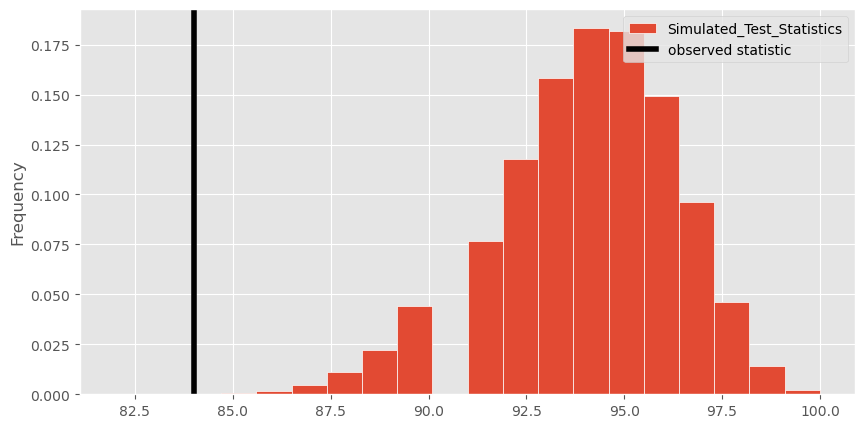

In [72]:
## Descomente e execute
# ----

## Definindo T_obs
T_obs = 84

## Elaborando o histograma
t = pd.DataFrame().assign(Simulated_Test_Statistics=simulated_distribution)
t.plot(kind='hist', density=True, ec='w', bins= 20, figsize=(10, 5))
plt.axvline(x=T_obs, color='black', label='observed statistic', linewidth=4)
plt.legend();

**Pergunta 2.5.** Modifique a célula de código abaixo para calcular o p-valor associado ao teste dessa questão, e atribua esse valor à `kingtriton_p_val`. Lembre que o p-valor pode ser informalmente definido como "a probabilidade de obtermos valores mais extremos do que $T_{obs}$", isto é, valores que nos levariam cada vez mais à rejeição de $H_0$.

_<u>Dica</u>_: use a função `np.count_nonzero` para contar o _número_ de valores de $T$ sob $H_0$ que satisfaçam a definição acima, e divida esse número pelo número de simulações `num_repetitions` definido na Pergunta 1.8 (ou utilizando a função `len` no DataFrame em questão, ou ainda utilizando `.shape[0]`).

In [ ]:
kingtriton_p_val = ...
kingtriton_p_val

Você deve ser capaz de perceber, tanto pelo histograma quanto pelo valor-p calculado, que o YouTube parece ter mais anúncios que não podem ser ignorados do que afirmam! 

Talvez eles tenham cometido um erro de digitação no anúncio e quisessem dizer 84% em vez de 94%...?

## Linha de chegada 🏁

Parabéns! Você concluiu o Laboratório 2 com sucesso 👏👏👏

Para enviar sua tarefa:

1. Selecione `Kernel -> Restart Kernel and Run All Cells` para garantir que você executou todas as células, incluindo as células de teste.
1. Leia o notebook do começo ao fim com cuidado para ter certeza de que está tudo bem e que todos os testes foram aprovados.
1. Baixe seu notebook usando `File -> Save and Export Notebook As -> HTML` e, em seguida, carregue seu notebook para o Moodle.